### Exploratory Data Analysis (EDA) - Datasets de Audio

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ─── Rutas Base ────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

NEUROVOZ_DIR = PROJECT_ROOT / 'data' / 'original' / 'neurovoz'
PCGITA_DIR = PROJECT_ROOT / 'data' / 'original' / 'pc-gita'

print(f"Project root: {PROJECT_ROOT}")

Project root: g:\Mi unidad\TFM-Data-Science


#### 1. Carga de Datos

In [2]:
# 1. Cargar las dos tablas de Neurovoz (Sanos y Enfermos)
df_neurovoz_hc = pd.read_csv(NEUROVOZ_DIR / 'metadata' / 'metadata_hc_vocales.csv')
df_neurovoz_pd = pd.read_csv(NEUROVOZ_DIR / 'metadata' / 'metadata_pd_vocales.csv')

# 2. Diferenciar cada grupo y unirlos en una sola gran tabla
df_neurovoz_hc['Label'] = 'HC'
df_neurovoz_pd['Label'] = 'PD'
df_neurovoz = pd.concat([df_neurovoz_hc, df_neurovoz_pd], ignore_index=True)

# 3. Preparar unas columnas extra para usar más adelante
df_neurovoz['Sex_label'] = df_neurovoz['Sex'].map({1.0: 'Hombre', 0.0: 'Mujer'})
df_neurovoz['Filename'] = df_neurovoz['Audio'].apply(lambda x: str(x).split('/')[-1] if pd.notna(x) else None)
df_neurovoz['Vowel'] = df_neurovoz['Audio'].apply(lambda x: str(x).split('/')[-2] if pd.notna(x) else None)

print(f"NeuroVoz: Tabla cargada correctamente con {len(df_neurovoz)} filas.")


NeuroVoz: Tabla cargada correctamente con 442 filas.


In [3]:
df_neurovoz.head(3)

,ID,Group,Date,Sex,Age,Diagnosis,Vocal tremor,Cephalic tremor,Mandibular tremor,Sialorrhoea,...,Occupation,Fiber/VocalFolds,Observations,Doctor,Audio,Label,Vocal folds analysis,Sex_label,Filename,Vowel
0,34,HC,2016-05-01,1.0,77.0,normal,0,0,0,0,...,retired,Not performed,NaN,NaN,data/audios_reorganizados/Control/E/0034_E2.wav,HC,NaN,Hombre,0034_E2.wav,E
1,34,HC,2016-05-01,1.0,77.0,normal,0,0,0,0,...,retired,Not performed,NaN,NaN,data/audios_reorganizados/Control/A/0034_A1.wav,HC,NaN,Hombre,0034_A1.wav,A
2,34,HC,2016-05-01,1.0,77.0,normal,0,0,0,0,...,retired,Not performed,NaN,NaN,data/audios_reorganizados/Control/E/0034_E3.wav,HC,NaN,Hombre,0034_E3.wav,E


In [4]:
# 1. Cargar la tabla de PC-GITA
df_pcgita = pd.read_excel(PCGITA_DIR / 'metadata' / 'Copia de PCGITA_metadata.xlsx', sheet_name='PD+HC')

# 2. Diferenciar enfermos de sanos analizando su ID (los sanos llevan una 'C' al final de 'AVPEPUDEAC')
df_pcgita['Label'] = df_pcgita['RECODING ORIGINAL NAME'].apply(lambda x: 'HC' if 'AVPEPUDEAC' in str(x) else 'PD')

# 3. Preparar la columna del sexo
df_pcgita['Sex_label'] = df_pcgita['SEX'].map({'M': 'Hombre', 'F': 'Mujer'})

print(f"PC-GITA: Tabla cargada correctamente con {len(df_pcgita)} pacientes.")


PC-GITA: Tabla cargada correctamente con 100 pacientes.


In [5]:
df_pcgita.head(5)

,RECODING ORIGINAL NAME,UPDRS,UPDRS-speech,H/Y,SEX,AGE,time after diagnosis,Label,Sex_label
0,AVPEPUDEA0001,28.0,1.0,2.0,M,64,3.0,PD,Hombre
1,AVPEPUDEA0002,19.0,0.0,1.0,F,72,2.5,PD,Mujer
2,AVPEPUDEA0003,52.0,2.0,3.0,F,75,3.0,PD,Mujer
3,AVPEPUDEA0005,32.0,1.0,2.0,M,65,12.0,PD,Hombre
4,AVPEPUDEA0006,28.0,1.0,2.0,F,66,4.0,PD,Mujer


#### 2. Exploración de los datos

In [6]:
# --- 1. Cálculos de NeuroVoz ---
nv_pat_hc = df_neurovoz[df_neurovoz['Label'] == 'HC']['ID'].nunique()
nv_pat_pd = df_neurovoz[df_neurovoz['Label'] == 'PD']['ID'].nunique()
nv_aud_hc = len(df_neurovoz[df_neurovoz['Label'] == 'HC'])
nv_aud_pd = len(df_neurovoz[df_neurovoz['Label'] == 'PD'])

nv_voc_hc = df_neurovoz[df_neurovoz['Label'] == 'HC']['Vowel'].value_counts().to_dict()
nv_voc_pd = df_neurovoz[df_neurovoz['Label'] == 'PD']['Vowel'].value_counts().to_dict()

# --- 2. Cálculos de PC-GITA ---
pg_pat_hc = len(df_pcgita[df_pcgita['Label'] == 'HC'])
pg_pat_pd = len(df_pcgita[df_pcgita['Label'] == 'PD'])

pg_aud_hc, pg_aud_pd = 0, 0
pg_voc_hc, pg_voc_pd = {}, {}

# Contamos los audios físicos de PC-GITA
for group, label, audio_dic in [('Control', 'HC', pg_voc_hc), ('Patologicas', 'PD', pg_voc_pd)]:
    for vowel in ['A', 'E', 'I', 'O', 'U']:
        path = PCGITA_DIR / 'audios' / group / vowel
        if path.exists():
            count = len([f for f in path.iterdir() if f.suffix == '.wav'])
            audio_dic[vowel] = count
            if label == 'HC': pg_aud_hc += count
            else: pg_aud_pd += count

# --- 3. Impresión del Reporte Completo ---
print("==========================================================")
print("       RESUMEN DE DATASETS       ")
print("==========================================================\n")

print("---------------------- NEUROVOZ --------------------------")
print(f"Pacientes sanos (HC):    {nv_pat_hc}")
print(f"Pacientes enfermos (PD): {nv_pat_pd}")
print(f"Total pacientes:         {nv_pat_hc + nv_pat_pd}\n")
print(f"Audios sanos (HC):       {nv_aud_hc}")
print(f"Audios enfermos (PD):    {nv_aud_pd}")
print(f"Total audios:            {nv_aud_hc + nv_aud_pd}\n")
print(f"Media audios/paciente HC: {nv_aud_hc/nv_pat_hc:.1f}")
print(f"Media audios/paciente PD: {nv_aud_pd/nv_pat_pd:.1f}\n")
print(f"Audios por Vocal (HC): " + ", ".join([f"{k}: {v}" for k, v in nv_voc_hc.items()]))
print(f"Audios por Vocal (PD): " + ", ".join([f"{k}: {v}" for k, v in nv_voc_pd.items()]))
print("\n")

print("---------------------- PC-GITA ---------------------------")
print(f"Pacientes sanos (HC):    {pg_pat_hc}")
print(f"Pacientes enfermos (PD): {pg_pat_pd}")
print(f"Total pacientes:         {pg_pat_hc + pg_pat_pd}\n")
print(f"Audios sanos (HC):       {pg_aud_hc}")
print(f"Audios enfermos (PD):    {pg_aud_pd}")
print(f"Total audios:            {pg_aud_hc + pg_aud_pd}\n")
print(f"Media audios/paciente HC: {pg_aud_hc/pg_pat_hc:.1f}")
print(f"Media audios/paciente PD: {pg_aud_pd/pg_pat_pd:.1f}\n")
print(f"Audios por Vocal (HC): " + ", ".join([f"{k}: {v}" for k, v in pg_voc_hc.items()]))
print(f"Audios por Vocal (PD): " + ", ".join([f"{k}: {v}" for k, v in pg_voc_pd.items()]))
print("\n==========================================================")


       RESUMEN DE DATASETS       

---------------------- NEUROVOZ --------------------------
Pacientes sanos (HC):    55
Pacientes enfermos (PD): 52
Total pacientes:         107

Audios sanos (HC):       190
Audios enfermos (PD):    252
Total audios:            442

Media audios/paciente HC: 3.5
Media audios/paciente PD: 4.8

Audios por Vocal (HC): A: 110, E: 80
Audios por Vocal (PD): A: 133, E: 119


---------------------- PC-GITA ---------------------------
Pacientes sanos (HC):    50
Pacientes enfermos (PD): 50
Total pacientes:         100

Audios sanos (HC):       300
Audios enfermos (PD):    300
Total audios:            600

Media audios/paciente HC: 6.0
Media audios/paciente PD: 6.0

Audios por Vocal (HC): A: 150, E: 150
Audios por Vocal (PD): A: 150, E: 150



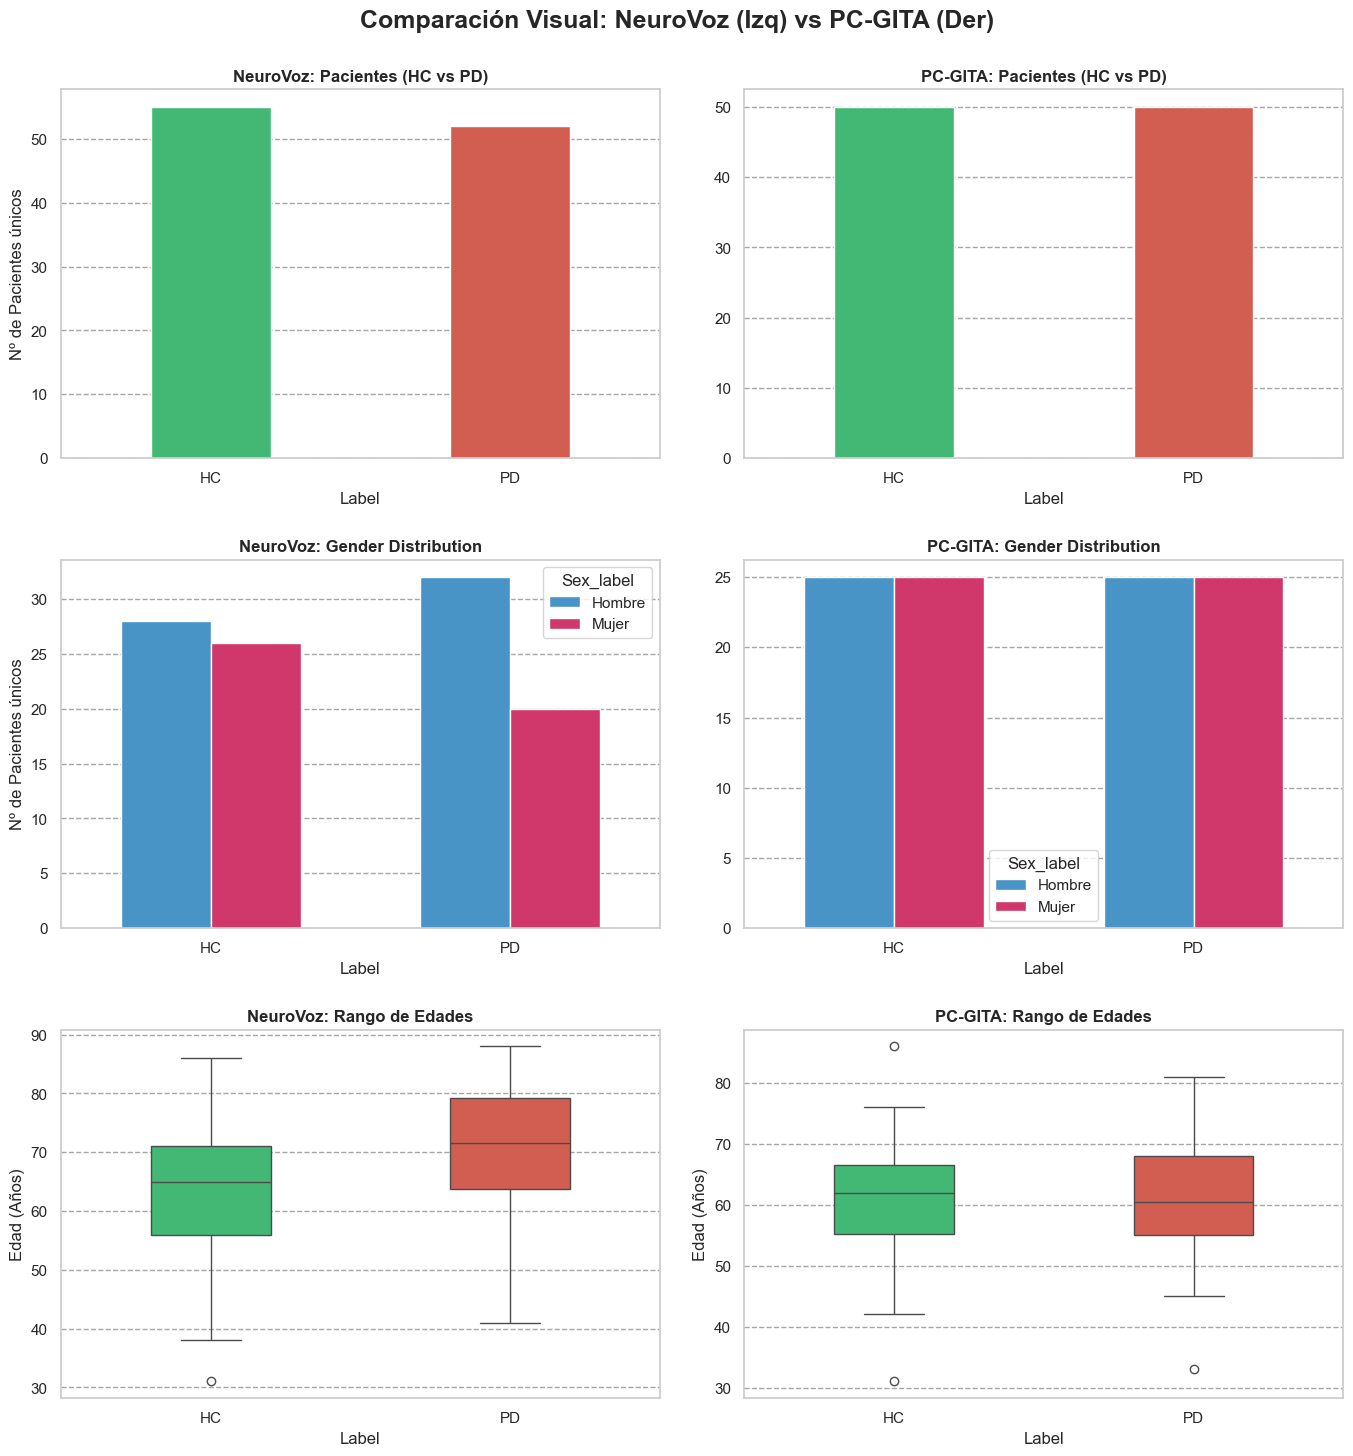

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Copias previas (Solo 1 paciente por fila)
df_nv_pacientes = df_neurovoz.drop_duplicates(subset=['ID', 'Label']).copy()
df_nv_pacientes['Age'] = pd.to_numeric(df_nv_pacientes['Age'], errors='coerce')
df_pcgita['AGE'] = pd.to_numeric(df_pcgita['AGE'], errors='coerce')

# 2. Configurar la figura (3 filas, 2 columnas) y forzar estilo con cuadrícula de fondo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle('Comparación Visual: NeuroVoz (Izq) vs PC-GITA (Der)', fontsize=18, fontweight='bold', y=0.98)

color_grupos = {'HC': '#2ecc71', 'PD': '#e74c3c'}
color_sexos = {'Hombre': '#3498db', 'Mujer': '#e91e63'}

# FUNCIÓN ÚTIL: Configura el fondo y las barras en cada sub-gráfico
def format_ax(ax):
    ax.grid(axis='y', linestyle='--', alpha=0.7, color='gray') # Líneas horizontales fondo
    ax.set_axisbelow(True)

# ----- FILA 1: PACIENTES HC VS PD (width=0.4 las hace más finas) -----
sns.countplot(data=df_nv_pacientes, x='Label', ax=axes[0, 0], palette=color_grupos, order=['HC', 'PD'], width=0.4)
axes[0, 0].set_title('NeuroVoz: Pacientes (HC vs PD)', fontweight='bold')
axes[0, 0].set_ylabel('Nº de Pacientes únicos')
format_ax(axes[0, 0])

sns.countplot(data=df_pcgita, x='Label', ax=axes[0, 1], palette=color_grupos, order=['HC', 'PD'], width=0.4)
axes[0, 1].set_title('PC-GITA: Pacientes (HC vs PD)', fontweight='bold')
axes[0, 1].set_ylabel('')
format_ax(axes[0, 1])

# ----- FILA 2: DISTRIBUCIÓN DE SEXO (width=0.6 como es doble, necesita un toque distinto) -----
sns.countplot(data=df_nv_pacientes, x='Label', hue='Sex_label', ax=axes[1, 0], palette=color_sexos, order=['HC', 'PD'], width=0.6)
axes[1, 0].set_title('NeuroVoz: Gender Distribution', fontweight='bold')
axes[1, 0].set_ylabel('Nº de Pacientes únicos')
format_ax(axes[1, 0])

sns.countplot(data=df_pcgita, x='Label', hue='Sex_label', ax=axes[1, 1], palette=color_sexos, order=['HC', 'PD'], width=0.6)
axes[1, 1].set_title('PC-GITA: Gender Distribution', fontweight='bold')
axes[1, 1].set_ylabel('')
format_ax(axes[1, 1])

# ----- FILA 3: DISTRIBUCIÓN DE EDADES -----
sns.boxplot(data=df_nv_pacientes, x='Label', y='Age', ax=axes[2, 0], palette=color_grupos, order=['HC', 'PD'], width=0.4)
axes[2, 0].set_title('NeuroVoz: Rango de Edades', fontweight='bold')
axes[2, 0].set_ylabel('Edad (Años)')
format_ax(axes[2, 0])

sns.boxplot(data=df_pcgita, x='Label', y='AGE', ax=axes[2, 1], palette=color_grupos, order=['HC', 'PD'], width=0.4)
axes[2, 1].set_title('PC-GITA: Rango de Edades', fontweight='bold')
axes[2, 1].set_ylabel('Edad (Años)')
format_ax(axes[2, 1])

plt.tight_layout(pad=2.0)
plt.show()


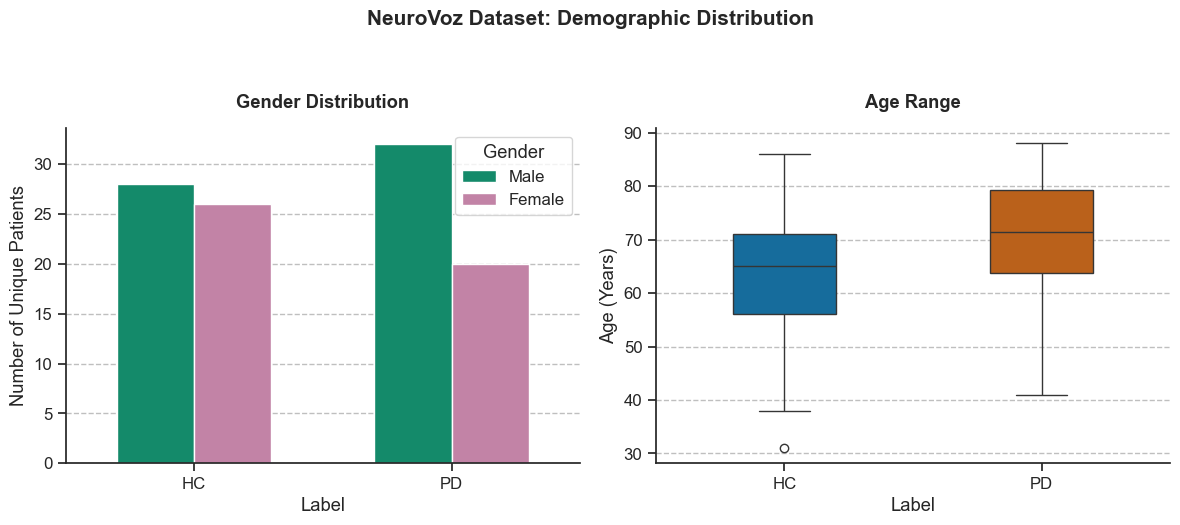

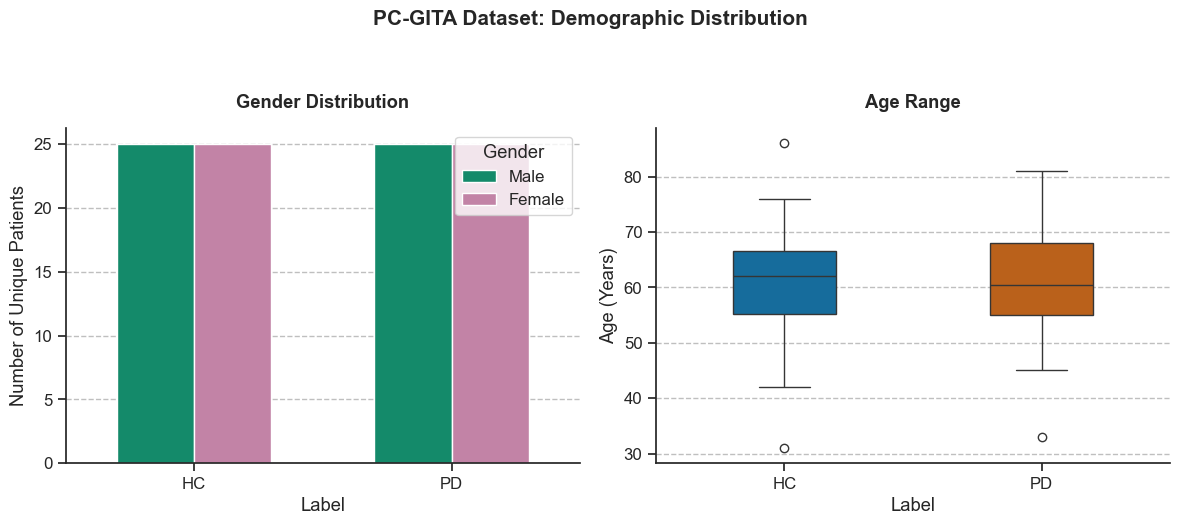

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Copias previas (Solo 1 paciente por fila)
df_nv_pacientes = df_neurovoz.drop_duplicates(subset=['ID', 'Label']).copy()
df_nv_pacientes['Age'] = pd.to_numeric(df_nv_pacientes['Age'], errors='coerce')
df_pcgita['AGE'] = pd.to_numeric(df_pcgita['AGE'], errors='coerce')

# Traducir etiquetas de género al inglés
if 'Sex_label' in df_nv_pacientes.columns:
    df_nv_pacientes['Sex_label'] = df_nv_pacientes['Sex_label'].replace({'Hombre': 'Male', 'Mujer': 'Female'})
if 'Sex_label' in df_pcgita.columns:
    df_pcgita['Sex_label'] = df_pcgita['Sex_label'].replace({'Hombre': 'Male', 'Mujer': 'Female'})

# 2. Configurar estilo general para Publicación / Reporte
sns.set_theme(style="ticks", font_scale=1.1)

# Paletas de colores "Colorblind-friendly" (Altamente recomendado para papers)
color_grupos = {'HC': '#0072B2', 'PD': '#D55E00'} # Azul profundo y Naranja Oscuro
color_sexos = {'Male': '#009E73', 'Female': '#CC79A7'} # Verde Turquesa y Rosa Púrpura

# FUNCIÓN ÚTIL: Limpia el gráfico y añade una cuadrícula sutil
def format_ax(ax):
    ax.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
    ax.set_axisbelow(True)
    sns.despine(ax=ax) # Elimina los bordes superior y derecho (look minimalista)

# ----- FIGURA 1: NEUROVOZ (Gender & Age) -----
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))
fig1.suptitle('NeuroVoz Dataset: Demographic Distribution', fontsize=15, fontweight='bold', y=1.05)

# Izquierda: Gender Distribution
sns.countplot(data=df_nv_pacientes, x='Label', hue='Sex_label', ax=axes1[0], palette=color_sexos, order=['HC', 'PD'], width=0.6)
axes1[0].set_title('Gender Distribution', fontweight='bold', pad=15)
axes1[0].set_ylabel('Number of Unique Patients')
axes1[0].legend(title='Gender', loc='upper right')
format_ax(axes1[0])

# Derecha: Age Range
sns.boxplot(data=df_nv_pacientes, x='Label', y='Age', ax=axes1[1], palette=color_grupos, order=['HC', 'PD'], width=0.4)
axes1[1].set_title('Age Range', fontweight='bold', pad=15)
axes1[1].set_ylabel('Age (Years)')
format_ax(axes1[1])

plt.tight_layout()
plt.savefig('neurovoz_demographics.png', dpi=300, bbox_inches='tight')
plt.show()

# ----- FIGURA 2: PC-GITA (Gender & Age) -----
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('PC-GITA Dataset: Demographic Distribution', fontsize=15, fontweight='bold', y=1.05)

# Izquierda: Gender Distribution
sns.countplot(data=df_pcgita, x='Label', hue='Sex_label', ax=axes2[0], palette=color_sexos, order=['HC', 'PD'], width=0.6)
axes2[0].set_title('Gender Distribution', fontweight='bold', pad=15)
axes2[0].set_ylabel('Number of Unique Patients')
axes2[0].legend(title='Gender', loc='upper right')
format_ax(axes2[0])

# Derecha: Age Range
sns.boxplot(data=df_pcgita, x='Label', y='AGE', ax=axes2[1], palette=color_grupos, order=['HC', 'PD'], width=0.4)
axes2[1].set_title('Age Range', fontweight='bold', pad=15)
axes2[1].set_ylabel('Age (Years)')
format_ax(axes2[1])

plt.tight_layout()
plt.savefig('pcgita_demographics.png', dpi=300, bbox_inches='tight')
plt.show()


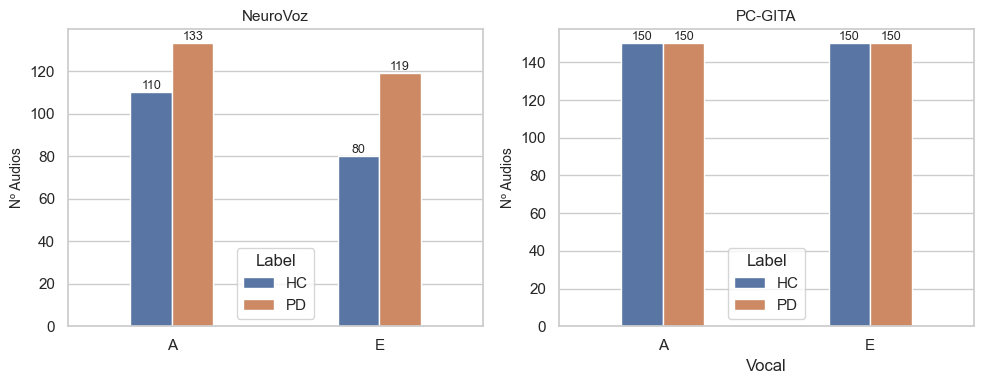

In [9]:
# ============================================================
# Distribución de audios por vocal y grupo
# ============================================================

# 1. Preparar conteo de audios de PC-GITA
vocales_pg = []
for group, label in [('Control', 'HC'), ('Patologicas', 'PD')]:
    for vowel in ['A', 'E']:
        path = PCGITA_DIR / 'audios' / group / vowel
        if path.exists():
            count = len([f for f in path.iterdir() if f.suffix.lower() == '.wav'])
            vocales_pg.append({'Vowel': vowel, 'Label': label, 'Audio_Count': count})

df_pcgita_audios = pd.DataFrame(vocales_pg)

# 2. Figura
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
orden_vocales = ['A', 'E']

# --- IZQUIERDA: NeuroVoz ---
sns.countplot(data=df_neurovoz,x='Vowel',hue='Label',ax=axes[0],order=orden_vocales,width=0.4)

# Añadir valores
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=9)

axes[0].set_title('NeuroVoz', fontsize=11)
axes[0].set_ylabel('Nº Audios', fontsize=10)
axes[0].set_xlabel('')

# --- DERECHA: PC-GITA ---
if not df_pcgita_audios.empty:
    sns.barplot(data=df_pcgita_audios,x='Vowel',y='Audio_Count',hue='Label',ax=axes[1],order=orden_vocales,width=0.4)

# Añadir valores
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=9)

axes[1].set_title('PC-GITA', fontsize=11)
axes[1].set_ylabel('Nº Audios', fontsize=10)
axes[1].set_xlabel('Vocal')

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Tabla: Distribución de edades
# ============================================================

import pandas as pd
from IPython.display import display, HTML

# 1. Aseguramos 1 fila por paciente y edades en formato numérico
df_nv_pac = df_neurovoz.drop_duplicates(subset=['ID', 'Label']).copy()
df_nv_pac['Age'] = pd.to_numeric(df_nv_pac['Age'], errors='coerce')
df_pcgita['AGE'] = pd.to_numeric(df_pcgita['AGE'], errors='coerce')

# 2. Función auxiliar para calcular todo de una tajada
def calcular_metricas(serie_edades):
    s = serie_edades.dropna()
    if s.empty:
        return "-", "-", "-", "-"
    return (
        f"{s.mean():.1f}", 
        f"{s.median():.1f}", 
        f"{s.std():.1f}", 
        f"{s.min():.0f} - {s.max():.0f}"
    )

# 3. Extraemos las columnas de datos
nv_hc_stats = calcular_metricas(df_nv_pac[df_nv_pac['Label'] == 'HC']['Age'])
nv_pd_stats = calcular_metricas(df_nv_pac[df_nv_pac['Label'] == 'PD']['Age'])
pg_hc_stats = calcular_metricas(df_pcgita[df_pcgita['Label'] == 'HC']['AGE'])
pg_pd_stats = calcular_metricas(df_pcgita[df_pcgita['Label'] == 'PD']['AGE'])

# 4. Construimos la tabla final
tabla_edades = pd.DataFrame({
    'Métrica': [' Media', ' Mediana', 'Desviación Estándar', '↔ Rango (Min - Max)'],
    'NeuroVoz (HC)': nv_hc_stats,
    'NeuroVoz (PD)': nv_pd_stats,
    'PC-GITA (HC)': pg_hc_stats,
    'PC-GITA (PD)': pg_pd_stats
})

# 5. La mostramos formateada en el Notebook
display(HTML("<h3 style='text-align:center;'>Estadísticas de Edad: Comparativa de Datasets</h3>"))
display(tabla_edades.set_index('Métrica'))


,NeuroVoz (HC),NeuroVoz (PD),PC-GITA (HC),PC-GITA (PD)
Métrica,,,,
Media,64.0,71.5,61.0,61.0
Mediana,65.0,71.5,62.0,60.5
Desviación Estándar,10.4,10.6,9.5,9.4
↔ Rango (Min - Max),31 - 86,41 - 88,31 - 86,33 - 81


##### 2.5 Variables Clínicas (solo PD)

In [11]:
import pandas as pd
from IPython.display import display, HTML

# 1. Nos quedamos solo con los datos de pacientes PD (1 fila por paciente)
pd_nv = df_neurovoz.drop_duplicates(subset=['ID', 'Label']).copy()
pd_nv = pd_nv[pd_nv['Label'] == 'PD']
pd_pg = df_pcgita[df_pcgita['Label'] == 'PD'].copy()

# 2. Buscamos automáticamente las columnas clínicas por su nombre
# (así evitamos errores si las variables se llaman distinto en cada dataset)
claves_clinicas = ['updrs', 'year', 'time', 'durat', 'hoehn', 'yahr']

cols_nv = [col for col in pd_nv.columns if any(c in col.lower() for c in claves_clinicas)]
cols_pg = [col for col in pd_pg.columns if any(c in col.lower() for c in claves_clinicas)]

# 3. Forzamos formato numérico y sacamos el super-resumen (Media, Min, Max, Std)
try:
    desc_nv = pd_nv[cols_nv].apply(pd.to_numeric, errors='coerce').describe().loc[['mean', 'std', 'min', 'max']].round(1)
except Exception:
    desc_nv = pd.DataFrame(["Sin datos numéricos"], columns=["Aviso"])

try:
    desc_pg = pd_pg[cols_pg].apply(pd.to_numeric, errors='coerce').describe().loc[['mean', 'std', 'min', 'max']].round(1)
except Exception:
    desc_pg = pd.DataFrame(["Sin datos numéricos"], columns=["Aviso"])

# 4. Renderizamos las dos tablitas estructuradas IZQ y DER mediante HTML
html = f"""
<h3 style="text-align: center; margin-bottom: 20px;">Resumen de Variables Clínicas (Solo Pacientes PD)</h3>
<div style="display: flex; flex-direction: row; justify-content: space-between; gap: 20px;">
    <div style="width: 48%; box-shadow: 2px 2px 10px rgba(0,0,0,0.1); padding: 15px; border-radius: 8px; background-color: #fcfcfc;">
        <h4 style="text-align: center; color: #9b59b6; margin-top: 0;">NeuroVoz (Izq)</h4>
        {desc_nv.to_html(classes='table table-sm', border=0, justify='center')}
    </div>
    <div style="width: 48%; box-shadow: 2px 2px 10px rgba(0,0,0,0.1); padding: 15px; border-radius: 8px; background-color: #fcfcfc;">
        <h4 style="text-align: center; color: #f39c12; margin-top: 0;">PC-GITA (Der)</h4>
        {desc_pg.to_html(classes='table table-sm', border=0, justify='center')}
    </div>
</div>
"""

display(HTML(html))


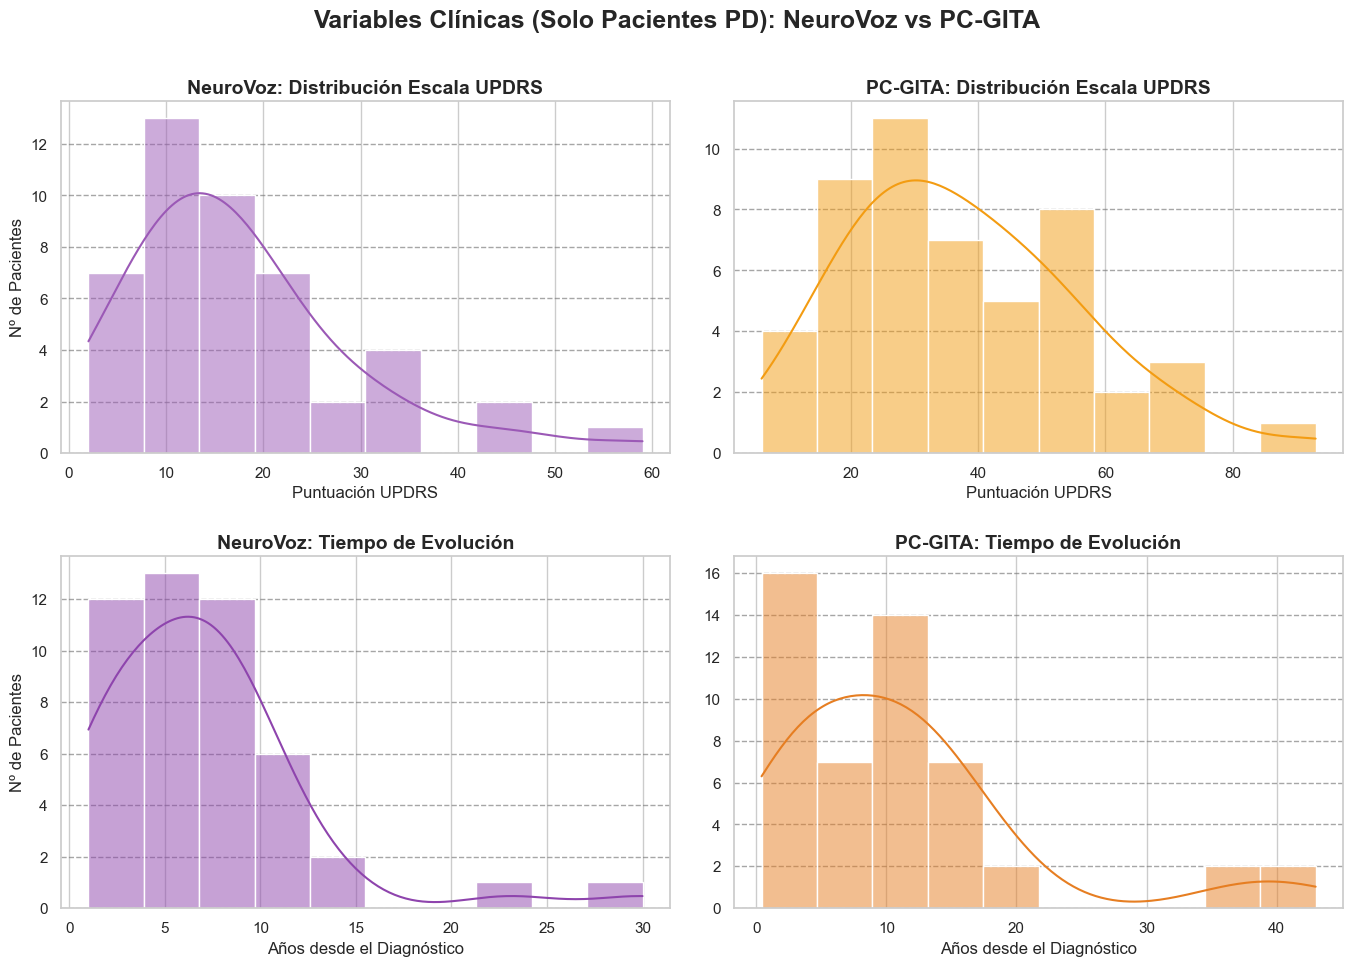

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparar datos (solo pacientes PD, filas únicas)
pd_nv = df_neurovoz.drop_duplicates(subset=['ID', 'Label']).copy()
pd_nv = pd_nv[pd_nv['Label'] == 'PD']

pd_pg = df_pcgita[df_pcgita['Label'] == 'PD'].copy()

# 2. Funciones seguras para extraer variables sin saber su nombre exacto
def get_col(df, keywords):
    for col in df.columns:
        if any(kw in col.lower() for kw in keywords):
            return col
    return None

# Encontramos la columna de UPDRS y la de Tiempo automáticamente
col_updrs_nv = get_col(pd_nv, ['updrs'])
col_updrs_pg = get_col(pd_pg, ['updrs'])

col_time_nv = get_col(pd_nv, ['year', 'time', 'durat', 'month'])
col_time_pg = get_col(pd_pg, ['year', 'time', 'durat', 'month'])

# 3. Forzar formato numérico y normalizar el PC-GITA a años (si venía en meses)
if col_updrs_nv: pd_nv[col_updrs_nv] = pd.to_numeric(pd_nv[col_updrs_nv], errors='coerce')
if col_updrs_pg: pd_pg[col_updrs_pg] = pd.to_numeric(pd_pg[col_updrs_pg], errors='coerce')

if col_time_nv: pd_nv['Evolucion_Anos'] = pd.to_numeric(pd_nv[col_time_nv], errors='coerce')
if col_time_pg: 
    temp_pg = pd.to_numeric(pd_pg[col_time_pg], errors='coerce')
    # Si la columna dice "month", lo dividimos por 12
    if 'month' in col_time_pg.lower():
        pd_pg['Evolucion_Anos'] = temp_pg / 12.0
    else:
        pd_pg['Evolucion_Anos'] = temp_pg

# 4. Configurar la Figura (2 filas, 2 columnas)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Variables Clínicas (Solo Pacientes PD): NeuroVoz vs PC-GITA', fontsize=18, fontweight='bold', y=0.98)

# ----- FILA 1: SEVERIDAD UPDRS -----
if col_updrs_nv:
    sns.histplot(pd_nv[col_updrs_nv].dropna(), bins=10, ax=axes[0, 0], color='#9b59b6', kde=True)
    axes[0, 0].set_title('NeuroVoz: Distribución Escala UPDRS', fontweight='bold', fontsize=14)
    axes[0, 0].set_xlabel('Puntuación UPDRS')
    axes[0, 0].set_ylabel('Nº de Pacientes')
    
if col_updrs_pg:
    sns.histplot(pd_pg[col_updrs_pg].dropna(), bins=10, ax=axes[0, 1], color='#f39c12', kde=True)
    axes[0, 1].set_title('PC-GITA: Distribución Escala UPDRS', fontweight='bold', fontsize=14)
    axes[0, 1].set_xlabel('Puntuación UPDRS')
    axes[0, 1].set_ylabel('')

# ----- FILA 2: AÑOS DE EVOLUCIÓN -----
if col_time_nv and 'Evolucion_Anos' in pd_nv.columns:
    sns.histplot(pd_nv['Evolucion_Anos'].dropna(), bins=10, ax=axes[1, 0], color='#8e44ad', kde=True)
    axes[1, 0].set_title('NeuroVoz: Tiempo de Evolución', fontweight='bold', fontsize=14)
    axes[1, 0].set_xlabel('Años desde el Diagnóstico')
    axes[1, 0].set_ylabel('Nº de Pacientes')
    
if col_time_pg and 'Evolucion_Anos' in pd_pg.columns:
    sns.histplot(pd_pg['Evolucion_Anos'].dropna(), bins=10, ax=axes[1, 1], color='#e67e22', kde=True)
    axes[1, 1].set_title('PC-GITA: Tiempo de Evolución', fontweight='bold', fontsize=14)
    axes[1, 1].set_xlabel('Años desde el Diagnóstico')
    axes[1, 1].set_ylabel('')

# Ajustes de rejilla y formato para todas las gráficas
for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
    ax.set_axisbelow(True)

plt.tight_layout(pad=2.0)
plt.show()


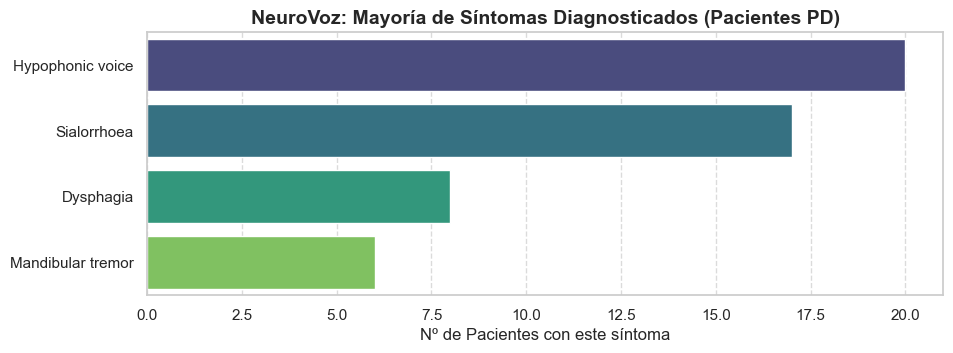

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# 1. Definimos las columnas específicas que contienen los "interruptores" de los síntomas
sintomas_cols = ['Tremor', 'Mandibular tremor', 'Sialorrhoea', 'Dysphagia', 'Hypophonic voice']

# Preparar pacientes PD únicos
pd_nv = df_neurovoz.drop_duplicates(subset=['ID', 'Label']).copy()
pd_nv = pd_nv[pd_nv['Label'] == 'PD']

pd_pg = df_pcgita[df_pcgita['Label'] == 'PD'].copy()

# 2. Función que recorre esas columnas específicas y cuenta los "Positivos" (1, Yes, etc)
def esparcir_sintomas(df_original, columnas_buscadas):
    conteos = {}
    
    # Identificar nombres reales de las columnas tolerando mayúsculas o espacios por equivocación
    cols_df_limpias = {c.strip().lower(): c for c in df_original.columns}
    cols_reales_en_dataset = [cols_df_limpias[s.strip().lower()] for s in columnas_buscadas if s.strip().lower() in cols_df_limpias]
            
    if not cols_reales_en_dataset:
        return None # Este dataset no tiene esas columnas
        
    for col in cols_reales_en_dataset:
        positivos = 0
        for val in df_original[col]:
            if pd.isna(val): continue
            
            val_str = str(val).strip().lower()
            # Asumimos que todo lo que no sea '0' o 'no' significa síntoma presente
            if val_str not in ['0', '0.0', 'no', 'none', 'false', 'n']:
                positivos += 1
        conteos[col] = positivos
        
    # Lo pasamos a DataFrame para que Seaborn pueda pintarlo fácilmente
    df_result = pd.DataFrame(list(conteos.items()), columns=['Síntoma', 'Pacientes (PD)'])
    
    # Ordenar de mayor a menor frecuencia
    return df_result.sort_values(by='Pacientes (PD)', ascending=False)


# Ejecutar el conteo
df_sintos_nv = esparcir_sintomas(pd_nv, sintomas_cols)
df_sintos_pg = esparcir_sintomas(pd_pg, sintomas_cols)

filas = sum([1 if df_sintos_nv is not None else 0, 1 if df_sintos_pg is not None else 0])

# 3. Pintar los Resultados
if filas == 0:
    display(HTML("<h4 style='color: #e74c3c;'>⚠️ No se ha encontrado NINGUNA de esas columnas en los datasets. Repasa los nombres exactos en tu Excel.</h4>"))
else:
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(filas, 1, figsize=(10, 4 * filas))
    if filas == 1: axes = [axes]
    
    ax_i = 0
    
    if df_sintos_nv is not None:
        sns.barplot(data=df_sintos_nv, y='Síntoma', x='Pacientes (PD)', ax=axes[ax_i], palette='viridis')
        axes[ax_i].set_title('NeuroVoz: Mayoría de Síntomas Diagnosticados (Pacientes PD)', fontweight='bold', fontsize=14)
        axes[ax_i].set_xlabel('Nº de Pacientes con este síntoma', fontsize=12)
        axes[ax_i].set_ylabel('')
        axes[ax_i].grid(axis='x', linestyle='--', alpha=0.7)
        ax_i += 1
        
    if df_sintos_pg is not None:
        sns.barplot(data=df_sintos_pg, y='Síntoma', x='Pacientes (PD)', ax=axes[ax_i], palette='magma')
        axes[ax_i].set_title('PC-GITA: Mayoría de Síntomas Diagnosticados (Pacientes PD)', fontweight='bold', fontsize=14)
        axes[ax_i].set_xlabel('Nº de Pacientes con este síntoma', fontsize=12)
        axes[ax_i].set_ylabel('')
        axes[ax_i].grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout(pad=2.0)
    plt.show()


#### 4 VISUALIZACION DE AUDIOS

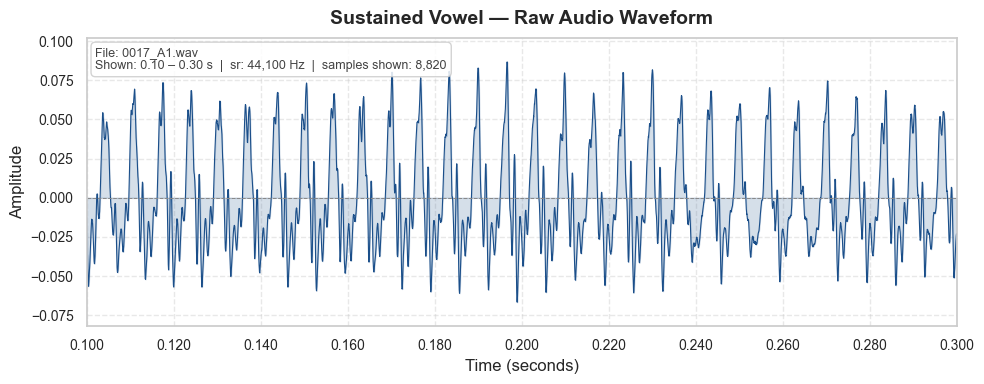

In [14]:
import random, glob, os, numpy as np, librosa
import matplotlib.pyplot as plt, matplotlib.ticker as ticker, seaborn as sns

# ╔══════════════════════════════════════════╗
# ║  PARÁMETROS — ajusta estos a tu gusto   ║
# ╠══════════════════════════════════════════╣
T_START    = 0.1        # segundo de inicio (float)
T_END      = 0.3        # segundo final     (float)
FIG_W      = 10        # ancho figura en pulgadas
FIG_H      = 4          # alto  figura en pulgadas
# ╚══════════════════════════════════════════╝

# -- Audio aleatorio de NeuroVoz (seed fija = reproducible)
_wavs = glob.glob(str(NEUROVOZ_DIR / 'audios' / '**' / '*.wav'), recursive=True)
random.seed(40)
path = random.choice(_wavs)

y, sr = librosa.load(path, sr=None)
dur   = len(y) / sr
t     = np.linspace(0, dur, len(y), endpoint=False)

# -- Recortar al intervalo deseado
t0 = max(0, T_START)
t1 = min(dur, T_END)
i0, i1 = int(t0 * sr), int(t1 * sr)
t_seg, y_seg = t[i0:i1], y[i0:i1]

# -- Figura
sns.set_theme(style='whitegrid')
C = '#1B4F8A'

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.fill_between(t_seg, y_seg, alpha=0.18, color=C)
ax.plot(t_seg, y_seg, color=C, linewidth=0.8)
ax.axhline(0, color='#888', linewidth=0.7, linestyle='--')

# Amplitud automática con un 10% de margen
_pad = (y_seg.max() - y_seg.min()) * 0.10 or 0.05
ax.set_ylim(y_seg.min() - _pad, y_seg.max() + _pad)
ax.set_xlim(t0, t1)

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)
ax.set_title('Sustained Vowel — Raw Audio Waveform', fontsize=14, fontweight='bold', pad=10)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
ax.tick_params(labelsize=10)
ax.grid(True, linestyle='--', alpha=0.45)
ax.margins(x=0)

# Caja de info
info = (f"File: {os.path.basename(path)}\n"
        f"Shown: {t0:.2f} – {t1:.2f} s  |  sr: {sr:,} Hz  |  samples shown: {len(y_seg):,}")
ax.text(0.01, 0.97, info, transform=ax.transAxes, fontsize=9,
        va='top', color='#444',
        bbox=dict(boxstyle='round,pad=0.35', fc='white', alpha=0.85, ec='#CCC'))

plt.tight_layout()
# plt.savefig('raw_waveform_example.pdf', dpi=150, bbox_inches='tight')
plt.show()


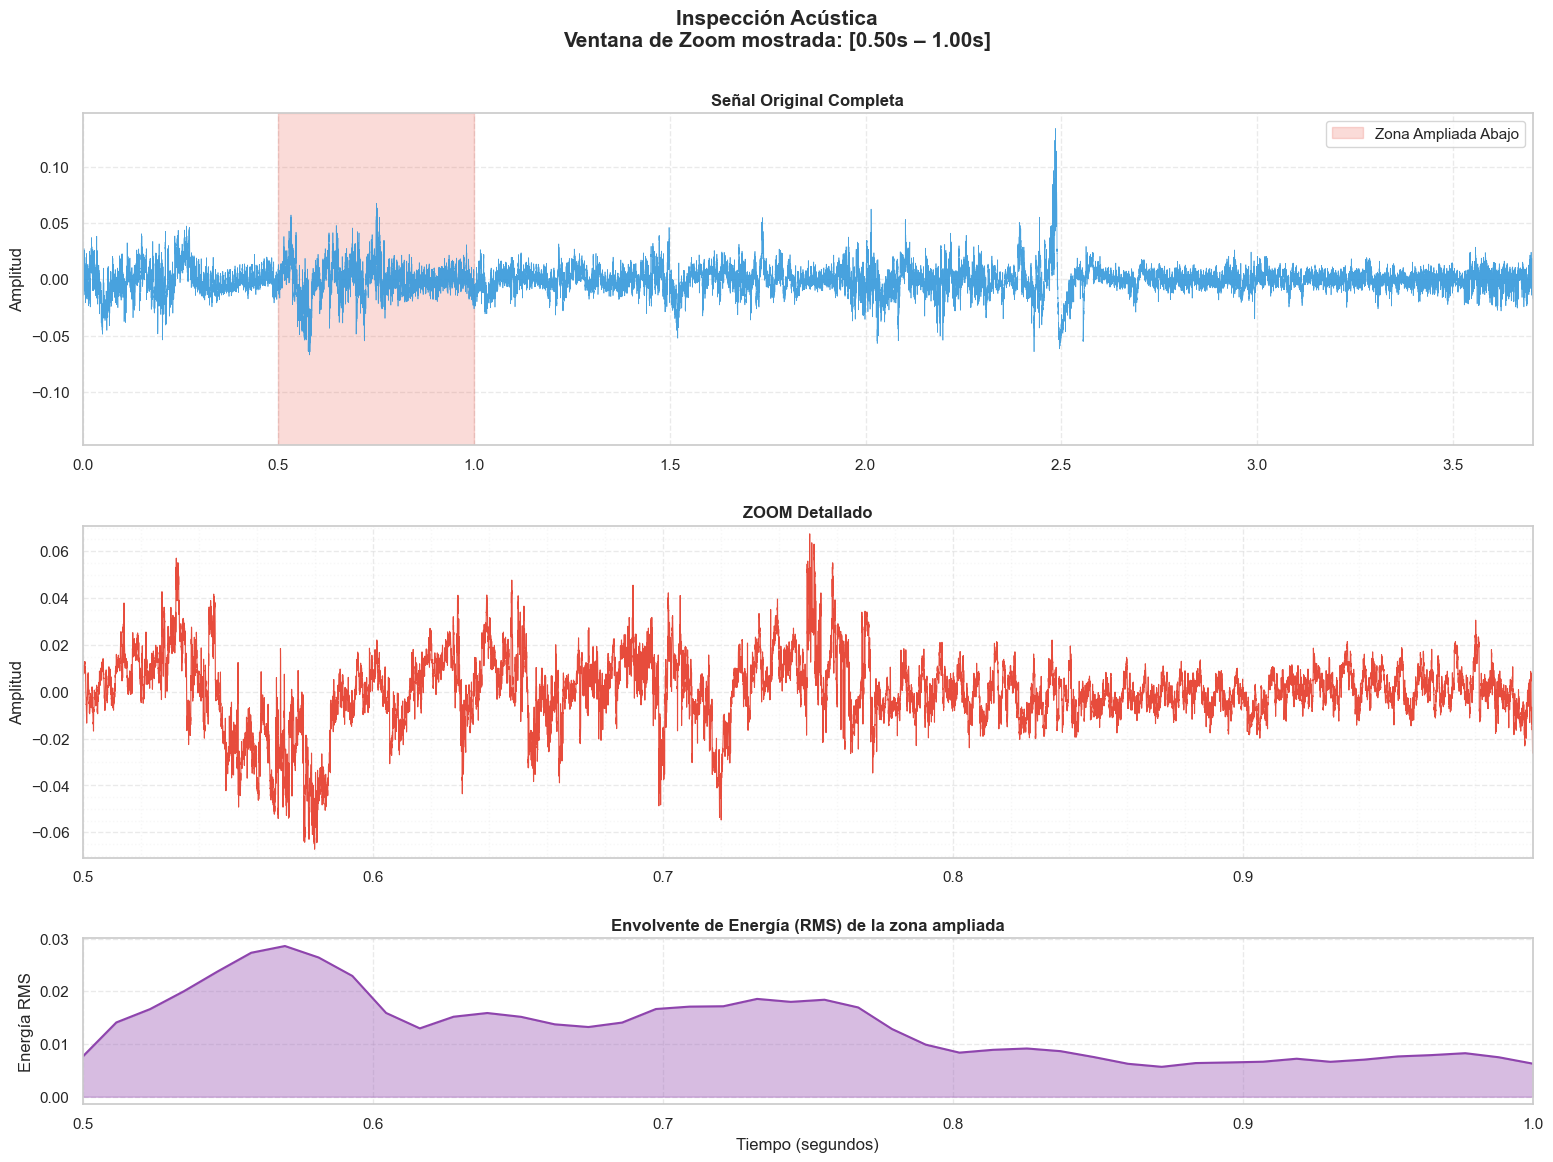

In [15]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
from IPython.display import display, HTML, Audio

# ============================================================
# 1. PARÁMETROS DEL VISOR Y ZOOM 🔍
# ============================================================
# audio_path = PCGITA_DIR / 'audios' / 'Control' / 'A' / 'AVPEPUDEAC0003a1.wav' 

# audio_path = NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0024_E2.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0022_E2.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0023_E2.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0007_E3.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0034_E3.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0078_E2.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0008_E3.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0011_E3.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0079_E2.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0012_E3.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0018_E2.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0004_E3.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0077_E2.wav'
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0014_E2.wav'

# Audio neurovoz con ruido
audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'A' / '0084_A1.wav'

# Audio neurovoz sin ruido
# audio_path = NEUROVOZ_DIR / 'audios' / 'Control' / 'A' / '0036_A2.wav'




# Define la "Ventana de Zoom" en segundos (sombreado rojo)
zoom_start_sec = 0.5   
zoom_end_sec = 1.0     

# ============================================================
# 2. CARGA DEL AUDIO ORIGINAL (Sin Normalizar)
# ============================================================
y, sr = librosa.load(audio_path, sr=None)
dur_total = len(y) / sr
max_amp_original = np.max(np.abs(y))

# Ajuste automático del Zoom por si ponemos un final mayor que el audio
t_ini_real = max(0, zoom_start_sec)
t_fin_real = min(dur_total, zoom_end_sec)
if t_ini_real >= t_fin_real:
    t_ini_real, t_fin_real = 0, dur_total 

# ============================================================
# 3. EXTRACCIÓN INTELIGENTE DE METADATOS CLÍNICOS
# ============================================================
filename = Path(audio_path).name
file_stem = Path(audio_path).stem  

dataset_str, label_str, sex_str = "-", "-", "-"
pat_id_str, vowel_str, rep_str = "-", "-", "-"

match_pat = re.search(r'(\d{4})', file_stem)
if match_pat: pat_id_str = match_pat.group(1)

match_vr = re.search(r'([aeiouAEIOU])(\d)', file_stem)
if match_vr:
    vowel_str = match_vr.group(1).upper()
    rep_str = match_vr.group(2)

# Cruzar con Pandas
match_nv = df_neurovoz[df_neurovoz['Filename'] == filename]
if not match_nv.empty:
    dataset_str = "NeuroVoz"
    label_str = match_nv['Label'].values[0]
    sex_str = match_nv['Sex_label'].values[0]
else:
    for _, row in df_pcgita.iterrows():
        if str(row['RECODING ORIGINAL NAME']) in filename:
            dataset_str = "PC-GITA"
            label_str = row['Label']
            sex_str = row['Sex_label']
            break

# ============================================================
# 4. TABLERO EN PANTALLA Y REPRODUCTOR
# ============================================================
badge_color = "#2ecc71" if label_str == "HC" else "#e74c3c" if label_str == "PD" else "#95a5a6"

resumen_html = f"""
<div style="border: 1px solid #dcdde1; padding: 20px; border-radius: 12px; font-size: 15px; background-color: #fcfcfc;">
    <h3 style="margin-top: 0; color: #2c3e50; border-bottom: 2px solid #eee; padding-bottom: 10px;">🔊 {filename}</h3>
    <div style="display: flex; justify-content: space-between;">
        <div style="width: 48%;">
            <h4 style="margin-bottom: 10px; color: #8e44ad;">📋 Ficha Clínica</h4>
            <ul style="list-style-type: none; padding-left: 0; line-height: 1.8;">
                <li><b>Dataset:</b> {dataset_str}</li>
                <li><b>Paciente (ID):</b> {pat_id_str}</li>
                <li><b>Condición:</b> <span style="background-color: {badge_color}; color: white; padding: 3px 10px; border-radius: 4px; font-weight: bold;">{label_str}</span></li>
                <li><b>Sexo:</b> {sex_str}</li>
            </ul>
        </div>
        <div style="width: 48%;">
            <h4 style="margin-bottom: 10px; color: #e67e22;">🎙️ Propiedades Físicas</h4>
            <ul style="list-style-type: none; padding-left: 0; line-height: 1.8;">
                <li><b>Vocal:</b> {vowel_str} <span style="color: #7f8c8d;">(Rep. nº {rep_str})</span></li>
                <li><b>Tasa Muestreo (Hz):</b> {sr} Hz</li>
                <li><b>Duración Total:</b> {dur_total:.2f} s</li>
                <li><b>Amplitud Max. Real:</b> {max_amp_original:.4f}</li>
            </ul>
        </div>
    </div>
</div>
"""
display(HTML(resumen_html))
display(Audio(data=y, rate=sr))

# ============================================================
# 5. MATRIZ DE VISUALIZACIÓN ACÚSTICA (Señal, Zoom y RMS)
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [2, 2, 1]})
fig.suptitle(f'Inspección Acústica\n'
             f'Ventana de Zoom mostrada: [{t_ini_real:.2f}s – {t_fin_real:.2f}s]',
             fontsize=15, fontweight='bold')

t_full = np.arange(len(y)) / sr

# Extraemos el segmento real (Zoom)
idx_ini = int(t_ini_real * sr)
idx_fin = int(t_fin_real * sr)
y_seg = y[idx_ini:idx_fin]
t_seg = t_full[idx_ini:idx_fin]

# --- Panel 1: Forma de onda completa ---
axes[0].plot(t_full, y, color='#3498db', linewidth=0.5, alpha=0.9)
axes[0].axvspan(t_ini_real, t_fin_real, alpha=0.2, color='#e74c3c', label='Zona Ampliada Abajo')
axes[0].set_title('Señal Original Completa', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Amplitud')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.4, linestyle='--')
axes[0].margins(x=0)

v_limit = max(0.1, max_amp_original * 1.1)
axes[0].set_ylim(-v_limit, v_limit)

# --- Panel 2: Zoom de la señal ---
axes[1].plot(t_seg, y_seg, color='#e74c3c', linewidth=0.8)
axes[1].set_title(f'ZOOM Detallado', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Amplitud')
amp_max = max(0.01, np.max(np.abs(y_seg)) * 1.05) if len(y_seg) > 0 else 1
axes[1].set_ylim(-amp_max, amp_max)
axes[1].grid(alpha=0.4, linestyle='--', which='both')
axes[1].minorticks_on()
axes[1].grid(alpha=0.15, linestyle=':', which='minor')
axes[1].margins(x=0)

# --- Panel 3: Envolvente de energía (RMS) ---
frame_length = min(2048, len(y_seg))
hop_length = max(1, frame_length // 4)

if len(y_seg) >= frame_length:
    rms = librosa.feature.rms(y=y_seg, frame_length=frame_length, hop_length=hop_length)[0]
    t_rms = np.linspace(t_ini_real, t_fin_real, len(rms))
    axes[2].fill_between(t_rms, rms, color='#9b59b6', alpha=0.4)
    axes[2].plot(t_rms, rms, color='#8e44ad', linewidth=1.5)
    axes[2].set_title('Envolvente de Energía (RMS) de la zona ampliada', fontweight='bold', fontsize=12)
else:
    axes[2].text(0.5, 0.5, 'Segmento demasiado corto para calcular RMS', ha='center', va='center')

axes[2].set_ylabel('Energía RMS')
axes[2].set_xlabel('Tiempo (segundos)')
axes[2].grid(alpha=0.4, linestyle='--')
axes[2].margins(x=0)

plt.tight_layout(pad=2.0)
plt.show()


In [16]:
import librosa
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore') 

print("🔍 Recolectando rutas de audios de forma estricta...")

# Búsqueda global recursiva (infalible)
archivos_pg = list(PCGITA_DIR.rglob('*.wav'))
archivos_nv = list(NEUROVOZ_DIR.rglob('*.wav'))

archivos_wav = archivos_pg + archivos_nv

print(f"✅ Se han encontrado {len(archivos_nv)} audios de NeuroVoz y {len(archivos_pg)} de PC-GITA.")
print("Analizando calidad acústica... (por favor, espera aprox 1 minuto)")

resultados_calidad = []

for i, path in enumerate(archivos_wav):
    try:
        y, sr = librosa.load(path, sr=None)
        if len(y) == 0: continue
        
        # 1. Planitud Espectral (identifica ruido estático constante)
        flatness = np.mean(librosa.feature.spectral_flatness(y=y))
        
        # 2. Cruces por Cero (ZCR) (detecta "chisporroteo" e interferencias)
        zcr = np.mean(librosa.feature.zero_crossing_rate(y=y))
        
        # 3. SNR (Mala relación voz/fondo)
        rms = librosa.feature.rms(y=y)[0]
        fondo = np.percentile(rms, 5) + 1e-9
        voz = np.percentile(rms, 95)
        snr_db = 20 * np.log10(voz / fondo)
        
        dataset = "PC-GITA" if "pc-gita" in str(path).lower() else "NeuroVoz"
        
        # Reconstruimos la ruta exacta en formato código de Python para el visor
        if dataset == "NeuroVoz":
            try:
                partes = [f"'{p}'" for p in path.relative_to(NEUROVOZ_DIR).parts]
                ruta_codigo = "NEUROVOZ_DIR / " + " / ".join(partes)
            except:
                ruta_codigo = str(path)
        else:
            try:
                partes = [f"'{p}'" for p in path.relative_to(PCGITA_DIR).parts]
                ruta_codigo = "PCGITA_DIR / " + " / ".join(partes)
            except:
                ruta_codigo = str(path)
        
        resultados_calidad.append({
            'Dataset': dataset,
            'Filename': path.name,
            'SNR_dB (↓ Peor)': snr_db,
            'ZCR (↑ Peor)': zcr,
            'Flatness (↑ Peor)': flatness,
            'Ruta para Copiar': ruta_codigo
        })
        
        if (i+1) % 200 == 0: print(f"  ... Analizados {i+1} de {len(archivos_wav)}")
            
    except Exception as e:
        continue

# Agrupar datos en DataFrame
df_calidad = pd.DataFrame(resultados_calidad)

print("\n⚙️ Generando Ranking de Calidad...")

# Vamos a ordenar detectando los que tienen altas tasas de ZCR combinadas con SNR bajo
df_peores_ruido = df_calidad.sort_values(by=['ZCR (↑ Peor)'], ascending=False).head(20)

display(HTML("<h3 style='color: #e74c3c;'>⚠️ TOP 20 AUDIOS MÁS RUIDOSOS (Copia la ruta y pégala en el Visor)</h3>"))

# Configurar pandas para que la columna de la ruta no se recorte/corte a medias
pd.set_option('display.max_colwidth', None)
display(df_peores_ruido[['Dataset', 'Filename', 'ZCR (↑ Peor)', 'SNR_dB (↓ Peor)', 'Ruta para Copiar']].reset_index(drop=True))
pd.reset_option('display.max_colwidth') # Restaurar config por defecto


🔍 Recolectando rutas de audios de forma estricta...
✅ Se han encontrado 454 audios de NeuroVoz y 600 de PC-GITA.
Analizando calidad acústica... (por favor, espera aprox 1 minuto)
  ... Analizados 200 de 1054
  ... Analizados 400 de 1054
  ... Analizados 600 de 1054
  ... Analizados 800 de 1054
  ... Analizados 1000 de 1054

⚙️ Generando Ranking de Calidad...


,Dataset,Filename,ZCR (↑ Peor),SNR_dB (↓ Peor),Ruta para Copiar
0,NeuroVoz,0024_E2.wav,0.410537,34.725986,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0024_E2.wav'
1,NeuroVoz,0022_E2.wav,0.406289,21.325069,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0022_E2.wav'
2,NeuroVoz,0023_E2.wav,0.400438,21.999439,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0023_E2.wav'
3,NeuroVoz,0007_E3.wav,0.390670,20.208971,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0007_E3.wav'
4,NeuroVoz,0034_E3.wav,0.382778,24.003420,NEUROVOZ_DIR / 'audios' / 'Control' / 'E' / '0034_E3.wav'
5,NeuroVoz,0078_E2.wav,0.381280,41.473484,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0078_E2.wav'
6,NeuroVoz,0008_E3.wav,0.379092,24.159424,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0008_E3.wav'
7,NeuroVoz,0011_E3.wav,0.378808,12.800444,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0011_E3.wav'
8,NeuroVoz,0079_E2.wav,0.378098,24.337051,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0079_E2.wav'
9,NeuroVoz,0012_E3.wav,0.370895,34.343781,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0012_E3.wav'


#### NORMALIZACION DE LONGITUD Y AMPLITUD

🔍 Analizando Propiedades Físicas Reales en ambos datasets... (Aprox. 1.5 minutos)







Dataset,Duración MÍNIMA (Capa de Corte),Duración Media,Duración Máxima
NeuroVoz,0.53327 s,3.9343 s,9.8895 s
PC-GITA,0.48891 s,2.9303 s,20.2222 s


PDF guardado: duration_distribution_comparison.pdf


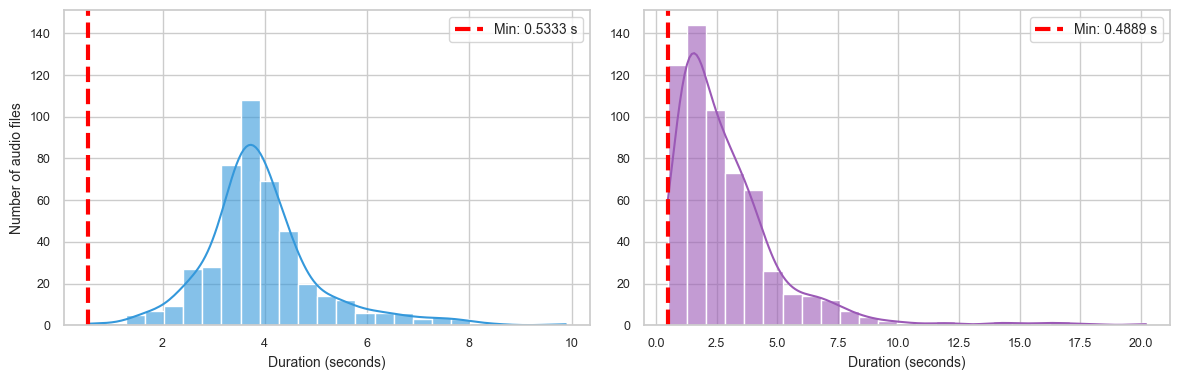

In [29]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')

print("🔍 Analizando Propiedades Físicas Reales en ambos datasets... (Aprox. 1.5 minutos)")

archivos_pg = list(PCGITA_DIR.rglob('*.wav'))
archivos_nv = list(NEUROVOZ_DIR.rglob('*.wav'))
todos_audios = archivos_pg + archivos_nv

datos_fisicos = []

for i, path in enumerate(todos_audios):
    try:
        y, sr = librosa.load(path, sr=None)
        if len(y) == 0: continue
        
        # 1. Duración matemática
        duracion = len(y) / sr
        
        # 2. Amplitud Media / Energía RMS de toda la señal
        amp_media = np.mean(librosa.feature.rms(y=y))
        
        # 3. Determinar Grupo por las carpetas (Evita cruces con los excel lentos)
        path_str = str(path).lower()
        if 'pc-gita' in path_str:
            dataset = "PC-GITA"
            label = "HC" if "control" in path_str or "pepudeac" in path.name.lower() else "PD"
        else:
            dataset = "NeuroVoz"
            label = "HC" if "control" in path_str else "PD"
            
        datos_fisicos.append({
            'Dataset': dataset,
            'Label': label,
            'Duración (s)': duracion,
            'Amplitud Media': amp_media
        })
        
        if (i+1) % 200 == 0: print(f"")
    except:
        pass

df_fisico = pd.DataFrame(datos_fisicos)

# Cortamos la tabla en dos partes
df_nv = df_fisico[df_fisico['Dataset'] == 'NeuroVoz']
df_pg = df_fisico[df_fisico['Dataset'] == 'PC-GITA']

min_dur_nv = df_nv['Duración (s)'].min()
min_dur_pg = df_pg['Duración (s)'].min()

# ============================================================
# 1. TABLA RESUMEN DE VALORES EXACTOS (NUEVO)
# ============================================================
stats_html = f"""
<div style="display: flex; justify-content: center; margin-bottom: 20px;">
    <table style="border-collapse: collapse; width: 80%; font-size: 15px; text-align: center; border: 1px solid #ddd; background-color: #fdfdfd; box-shadow: 2px 2px 8px rgba(0,0,0,0.05);">
        <tr style="background-color: #f2f2f2;">
            <th style="padding: 12px; border: 1px solid #ddd;">Dataset</th>
            <th style="padding: 12px; border: 1px solid #ddd;">Duración MÍNIMA (Capa de Corte)</th>
            <th style="padding: 12px; border: 1px solid #ddd;">Duración Media</th>
            <th style="padding: 12px; border: 1px solid #ddd;">Duración Máxima</th>
        </tr>
        <tr>
            <td style="padding: 12px; border: 1px solid #ddd; font-weight: bold; color: #2980b9;">NeuroVoz</td>
            <td style="padding: 12px; border: 1px solid #ddd; color: #e74c3c; font-weight: bold;">{min_dur_nv:.5f} s</td>
            <td style="padding: 12px; border: 1px solid #ddd;">{df_nv['Duración (s)'].mean():.4f} s</td>
            <td style="padding: 12px; border: 1px solid #ddd;">{df_nv['Duración (s)'].max():.4f} s</td>
        </tr>
        <tr>
            <td style="padding: 12px; border: 1px solid #ddd; font-weight: bold; color: #8e44ad;">PC-GITA</td>
            <td style="padding: 12px; border: 1px solid #ddd; color: #e74c3c; font-weight: bold;">{min_dur_pg:.5f} s</td>
            <td style="padding: 12px; border: 1px solid #ddd;">{df_pg['Duración (s)'].mean():.4f} s</td>
            <td style="padding: 12px; border: 1px solid #ddd;">{df_pg['Duración (s)'].max():.4f} s</td>
        </tr>
    </table>
</div>
"""
display(HTML(stats_html))


# ============================================================
# 2. PINTADO DEL DIAGNÓSTICO GRÁFICO - DURACIONES SOLO
# ============================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- IZQUIERDA: NeuroVoz DURACIONES ---
sns.histplot(data=df_nv, x='Duración (s)', ax=axes[0], color='#3498db', kde=True, bins=25, alpha=0.6)
axes[0].axvline(min_dur_nv, color='red', linestyle='--', linewidth=3, label=f'Min: {min_dur_nv:.4f} s')
axes[0].set_ylabel('Number of audio files', fontsize=10)
axes[0].set_xlabel('Duration (seconds)', fontsize=10)
axes[0].tick_params(labelsize=9)
axes[0].legend(loc='upper right', fontsize=10, frameon=True)

# --- DERECHA: PC-GITA DURACIONES ---
sns.histplot(data=df_pg, x='Duración (s)', ax=axes[1], color='#9b59b6', kde=True, bins=25, alpha=0.6)
axes[1].axvline(min_dur_pg, color='red', linestyle='--', linewidth=3, label=f'Min: {min_dur_pg:.4f} s')
axes[1].set_ylabel('', fontsize=10)
axes[1].set_xlabel('Duration (seconds)', fontsize=10)
axes[1].tick_params(labelsize=9)
axes[1].legend(loc='upper right', fontsize=10, frameon=True)

# Igualar escalas Y
ylim_top = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(0, ylim_top)
axes[1].set_ylim(0, ylim_top)

plt.tight_layout(pad=1.2)
fig.savefig('duration_distribution_comparison.pdf', format='pdf', bbox_inches='tight')
print('PDF guardado: duration_distribution_comparison.pdf')
plt.show()

paleta = {'HC': '#2ecc71', 'PD': '#e74c3c'}


🔍 Comparando Amplitud Media entre HC y PD por dataset


,Dataset,N HC,N PD,HC media,PD media,HC mediana,PD mediana,t-stat,p-value,p < 0.05
0,NeuroVoz,199,255,0.034671,0.044391,0.022034,0.021177,-1.7330,0.0839,No
1,PC-GITA,300,300,0.030250,0.025761,0.013597,0.021393,1.4686,0.1428,No


PDF guardado: amplitude_neurovoz.pdf


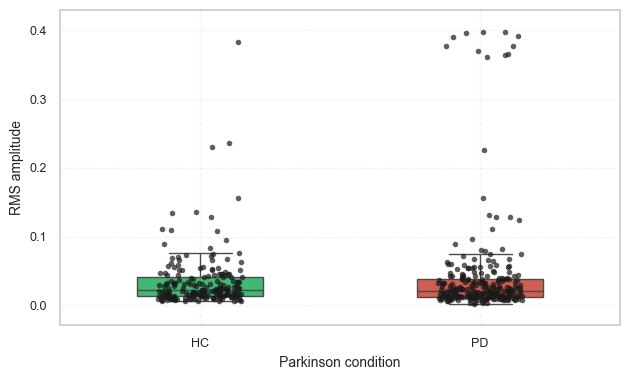

PDF guardado: amplitude_pc_gita.pdf


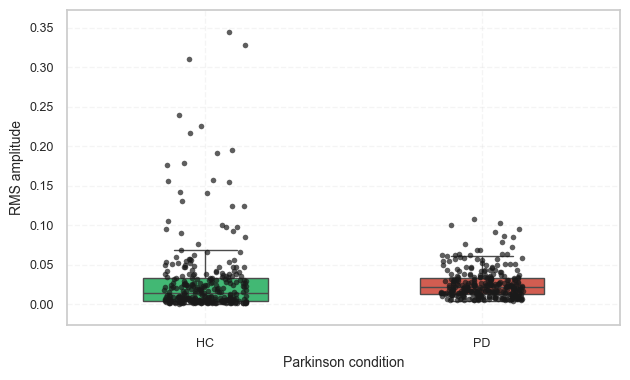

In [26]:
import scipy.stats as stats

# === ANÁLISIS DE AMPLITUD POR DATASET ===
print("🔍 Comparando Amplitud Media entre HC y PD por dataset")

summary_rows = []
for dataset, df_set in [('NeuroVoz', df_nv), ('PC-GITA', df_pg)]:
    hc_vals = df_set.loc[df_set['Label'] == 'HC', 'Amplitud Media']
    pd_vals = df_set.loc[df_set['Label'] == 'PD', 'Amplitud Media']
    n_hc, n_pd = len(hc_vals), len(pd_vals)

    if n_hc > 0 and n_pd > 0:
        t_stat, p_t = stats.ttest_ind(hc_vals, pd_vals, equal_var=False)
        significant = 'Sí' if p_t < 0.05 else 'No'
        mean_hc, mean_pd = hc_vals.mean(), pd_vals.mean()
        med_hc, med_pd = hc_vals.median(), pd_vals.median()
    else:
        t_stat, p_t = np.nan, np.nan
        significant = 'N/A'
        mean_hc = mean_pd = med_hc = med_pd = np.nan

    summary_rows.append({
        'Dataset': dataset,
        'N HC': n_hc,
        'N PD': n_pd,
        'HC media': mean_hc,
        'PD media': mean_pd,
        'HC mediana': med_hc,
        'PD mediana': med_pd,
        't-stat': t_stat,
        'p-value': p_t,
        'p < 0.05': significant
    })

summary_table = pd.DataFrame(summary_rows)
summary_table = summary_table[['Dataset', 'N HC', 'N PD', 'HC media', 'PD media', 'HC mediana', 'PD mediana', 't-stat', 'p-value', 'p < 0.05']]

display(HTML('<h3>Resumen estadístico de amplitud por dataset</h3>'))
display(summary_table.style.format({
    'HC media': '{:.6f}',
    'PD media': '{:.6f}',
    'HC mediana': '{:.6f}',
    'PD mediana': '{:.6f}',
    't-stat': '{:.4f}',
    'p-value': '{:.4f}'
}))
display(HTML('<p><b>Criterio t-test:</b> p < 0.05 indica diferencia estadísticamente significativa entre HC y PD.</p>'))

# Configura aquí el tamaño de las figuras para las gráficas de amplitud
FIG_SIZE_WIDTH = 6.5
FIG_SIZE_HEIGHT = 4

for dataset, df_set in [('NeuroVoz', df_nv), ('PC-GITA', df_pg)]:
    df_plot = df_set.copy()
    df_plot['Label'] = pd.Categorical(df_plot['Label'], categories=['HC', 'PD'])

    fig, ax = plt.subplots(figsize=(FIG_SIZE_WIDTH, FIG_SIZE_HEIGHT))
    sns.boxplot(data=df_plot, x='Label', y='Amplitud Media', ax=ax, palette=paleta, order=['HC', 'PD'], width=0.45, showfliers=False)
    sns.stripplot(data=df_plot, x='Label', y='Amplitud Media', ax=ax, color='k', size=4, jitter=0.15, alpha=0.7, order=['HC', 'PD'])

    ax.set_ylabel('RMS amplitude', fontsize=10)
    ax.set_xlabel('Parkinson condition', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(alpha=0.2, linestyle='--')

    values = df_plot['Amplitud Media'].dropna()
    if len(values) > 0:
        vmin, vmax = values.min(), values.max()
        padding = max((vmax - vmin) * 0.08, 0.00001)
        ax.set_ylim(vmin - padding, vmax + padding)

    plt.tight_layout(pad=1.2)
    filename = f'amplitude_{dataset.lower().replace("-", "_")}.pdf'
    fig.savefig(filename, format='pdf', bbox_inches='tight')
    print(f'PDF guardado: {filename}')
    plt.show()


Hz (frecuencia de muestreo) — es cuántas "fotografías" por segundo se toman de la señal de audio. 16.000 Hz = 16.000 muestras por segundo. Esto lo estandarizas a 16kHz en todos los audios simplemente para que todos los modelos reciban el mismo tipo de entrada. No tiene nada que ver con la enfermedad.
Amplitud (volumen) — aquí has tocado un punto muy relevante para tu TFM. Tienes razón en dudar. La hipofonía (voz débil, poca amplitud) es uno de los síntomas clínicos del Parkinson — de hecho está en tu propia columna Hypophonic voice del metadata. Entonces normalizar la amplitud eliminaría información clínicamente relevante. Sin embargo, si no normalizas, los modelos pueden aprender diferencias de volumen debidas al micrófono o la distancia al micro, no a la enfermedad.

Esto nos demuestra que podemos normalizar los amplitudes, ya que no hay diferencia significativa entre enferemos y sanos, por lo que conviene normalizar ya que no parece que se vaya a perder informacion relevante, y sin embargo, si vamos a evitar que el modelo no aprenda caracterisitcas propias de la distancia al microfono,  u otras características que no son determinantes en la deteccion de la enfermedad.


 no se puede separar la diferencia de amplitud debida a causas clínicas de la debida a condiciones de grabación, por lo que se normaliza para que el modelo aprenda únicamente de la forma de la onda y no de su escala absoluta

#### ANALISIS DE SILENCIOS

In [19]:
import librosa
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')

# 1. Configuración de escaneo
SILENCE_TOP_DB = 30  # Ajustado al último valor que decidiste probar (muy poco agresivo)
archivos_pg = list(PCGITA_DIR.rglob('*.wav'))
archivos_nv = list(NEUROVOZ_DIR.rglob('*.wav'))
todos_audios = archivos_pg + archivos_nv

# 2. Análisis de Extremos
datos_silencios = []

for path in tqdm(todos_audios, desc=f"Escaneando Silencios (dB: {SILENCE_TOP_DB})"):
    try:
        y, sr = librosa.load(path, sr=None)
        if len(y) == 0: continue
        
        # 'trim' simula el corte SÓLO por la izquierda y la derecha
        y_trimmed, index = librosa.effects.trim(y, top_db=SILENCE_TOP_DB)
        
        if len(y_trimmed) < len(y):
            dur_original = len(y) / sr
            dur_recortada = len(y_trimmed) / sr
            segundos_silencio = dur_original - dur_recortada
            
            # Filtramos micro-silencios inapreciables (<0.01s) para que solo te avise de los graves
            if segundos_silencio > 0.01:
                dataset = "PC-GITA" if "pc-gita" in str(path).lower() else "NeuroVoz"
                
                # Reconstruir la ruta formato código
                if dataset == "NeuroVoz":
                    try:
                        partes = [f"'{p}'" for p in path.relative_to(NEUROVOZ_DIR).parts]
                        ruta_codigo = "NEUROVOZ_DIR / " + " / ".join(partes)
                    except:
                        ruta_codigo = str(path)
                else:
                    try:
                        partes = [f"'{p}'" for p in path.relative_to(PCGITA_DIR).parts]
                        ruta_codigo = "PCGITA_DIR / " + " / ".join(partes)
                    except:
                        ruta_codigo = str(path)
                        
                datos_silencios.append({
                    'Dataset': dataset,
                    'Archivo': path.name,
                    'Segundos Extirpados': float(segundos_silencio),
                    'Ruta Python': ruta_codigo
                })
    except:
        continue

# 3. Mostrar Resultados Clasificados
df_silencios = pd.DataFrame(datos_silencios)

if df_silencios.empty:
    display(HTML(f"<h3 style='color: #2ecc71;'>✅ ¡Genial! Ningún audio tiene silencios detectables (a {SILENCE_TOP_DB}dB)</h3>"))
else:
    # Ordenar por los que tenían MÁS silencio primero
    df_silencios = df_silencios.sort_values(by='Segundos Extirpados', ascending=False)
    
    display(HTML(f"<h3 style='color: #8e44ad;'>✂️ ESTUDIO DE SILENCIOS DE EXTREMOS (Top_dB: {SILENCE_TOP_DB})</h3>"))
    display(HTML(f"<p style='font-size: 15px;'><b>Total de audios gravemente afectados:</b> {len(df_silencios)} de {len(todos_audios)}</p>"))
    
    pd.set_option('display.max_colwidth', None)
    display(df_silencios.reset_index(drop=True))
    pd.reset_option('display.max_colwidth')

Escaneando Silencios (dB: 30):   0%|          | 0/1054 [00:00<?, ?it/s]

,Dataset,Archivo,Segundos Extirpados,Ruta Python
0,NeuroVoz,0084_A2.wav,0.325079,NEUROVOZ_DIR / 'audios' / 'Control' / 'A' / '0084_A2.wav'
1,NeuroVoz,0024_E2.wav,0.162540,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0024_E2.wav'
2,NeuroVoz,0078_E2.wav,0.133401,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0078_E2.wav'
3,NeuroVoz,0033_E1.wav,0.129456,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0033_E1.wav'
4,NeuroVoz,0012_E3.wav,0.127710,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'E' / '0012_E3.wav'
5,PC-GITA,AVPEPUDEA0035e3.wav,0.088934,PCGITA_DIR / 'audios' / 'Patologicas' / 'E' / 'AVPEPUDEA0035e3.wav'
6,PC-GITA,AVPEPUDEA0035e2.wav,0.078209,PCGITA_DIR / 'audios' / 'Patologicas' / 'E' / 'AVPEPUDEA0035e2.wav'
7,NeuroVoz,0070_A1.wav,0.069660,NEUROVOZ_DIR / 'audios' / 'Patologicas' / 'A' / '0070_A1.wav'
8,PC-GITA,AVPEPUDEA0035a3.wav,0.064490,PCGITA_DIR / 'audios' / 'Patologicas' / 'A' / 'AVPEPUDEA0035a3.wav'
9,PC-GITA,AVPEPUDEA0046e1.wav,0.058186,PCGITA_DIR / 'audios' / 'Patologicas' / 'E' / 'AVPEPUDEA0046e1.wav'


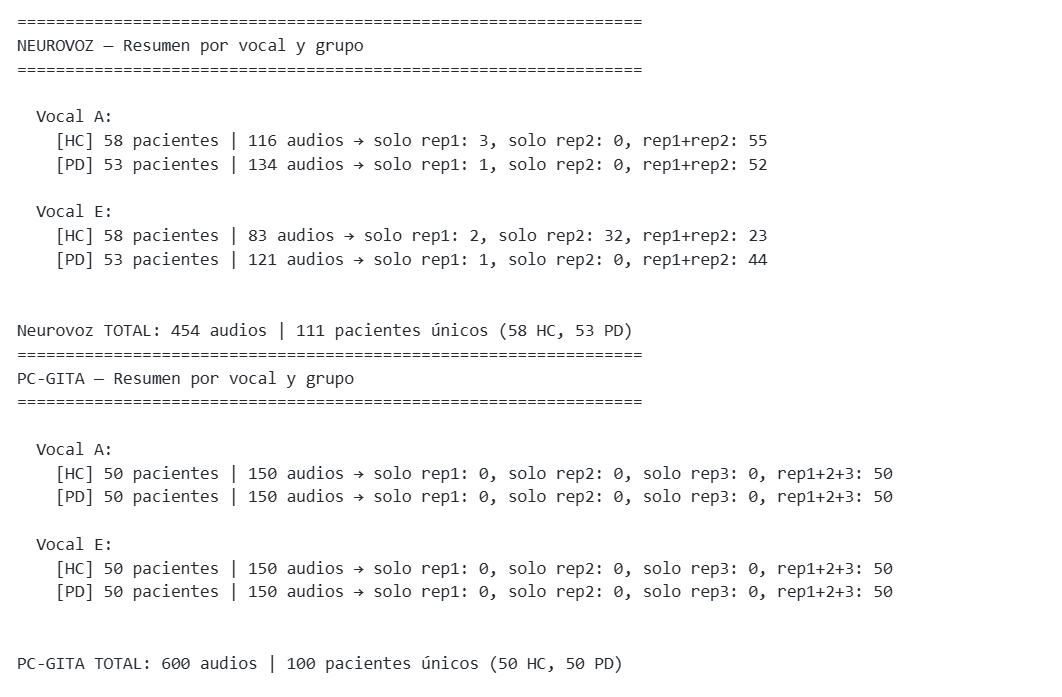